# Project Overview: Binary Prediction of Poisonous Mushrooms

**Objective:** Predict the crop yield of wild blueberries using environmental, bees pollination, and weather-specific dynamics.

## 1. Libraries & Workspace Setup

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s4e8')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s4e8


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pickle
import joblib

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [91]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')

In [5]:
train_df.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [6]:
test_df.head()

,id,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,3116945,8.64,x,NaN,n,t,NaN,NaN,w,11.13,...,b,NaN,w,u,w,t,g,NaN,d,a
1,3116946,6.90,o,t,o,f,NaN,c,y,1.27,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
2,3116947,2.00,b,g,n,f,NaN,c,n,6.18,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,s
3,3116948,3.47,x,t,n,f,s,c,n,4.98,...,NaN,NaN,w,NaN,n,t,z,NaN,d,u
4,3116949,6.17,x,h,y,f,p,NaN,y,6.73,...,NaN,NaN,y,NaN,y,t,NaN,NaN,d,u


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2077964 entries, 0 to 2077963
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   cap-diameter          float64
 2   cap-shape             object 
 3   cap-surface           object 
 4   cap-color             object 
 5   does-bruise-or-bleed  object 
 6   gill-attachment       object 
 7   gill-spacing          object 
 8   gill-color            object 
 9   stem-height           float64
 10  stem-width            float64
 11  stem-root             object 
 12  stem-surface          object 
 13  stem-color            object 
 14  veil-type             object 
 15  veil-color            object 
 16  has-ring              object 
 17  ring-type             object 
 18  spore-print-color     object 
 19  habitat               object 
 20  season                object 
dtypes: float64(3), int64(1), object(17)
memory usage: 332.9+ MB


In [9]:
train_df.shape

(3116945, 22)

In [10]:
test_df.shape

(2077964, 21)

In [11]:
train_df.isnull().sum()

id                            0
class                         0
cap-diameter                  4
cap-shape                    40
cap-surface              671023
cap-color                    12
does-bruise-or-bleed          8
gill-attachment          523936
gill-spacing            1258435
gill-color                   57
stem-height                   0
stem-width                    0
stem-root               2757023
stem-surface            1980861
stem-color                   38
veil-type               2957493
veil-color              2740947
has-ring                     24
ring-type                128880
spore-print-color       2849682
habitat                      45
season                        0
dtype: int64

In [12]:
test_df.isnull().sum()

id                            0
cap-diameter                  7
cap-shape                    31
cap-surface              446904
cap-color                    13
does-bruise-or-bleed         10
gill-attachment          349821
gill-spacing             839595
gill-color                   49
stem-height                   1
stem-width                    0
stem-root               1838012
stem-surface            1321488
stem-color                   21
veil-type               1971545
veil-color              1826124
has-ring                     19
ring-type                 86195
spore-print-color       1899617
habitat                      25
season                        0
dtype: int64

## 3. Exploratory Data Analysis

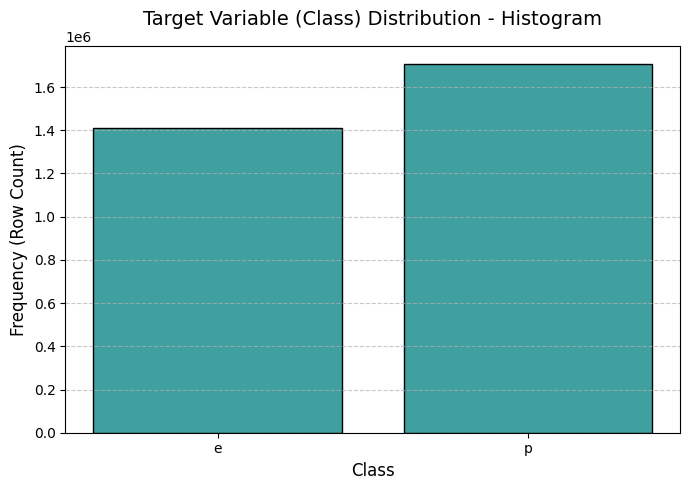

In [13]:
plt.figure(figsize=(7, 5))

sns.histplot(data=train_df, x='class', shrink=0.8, color='teal', edgecolor='black')

plt.title('Target Variable (Class) Distribution - Histogram', fontsize=14, pad=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Frequency (Row Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

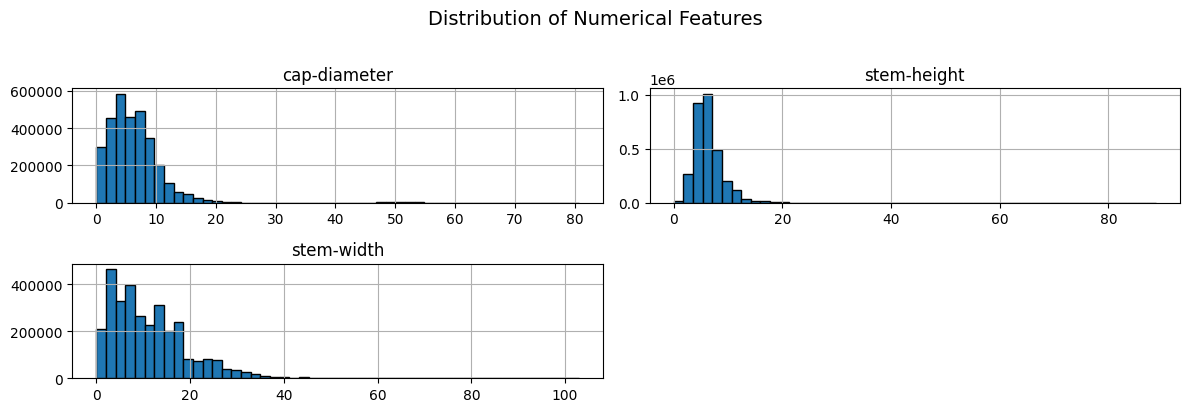

In [14]:
num_cols = ['cap-diameter', 'stem-height', 'stem-width']

# Histogram for numerical distributions
train_df[num_cols].hist(bins=50, figsize=(12, 4), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

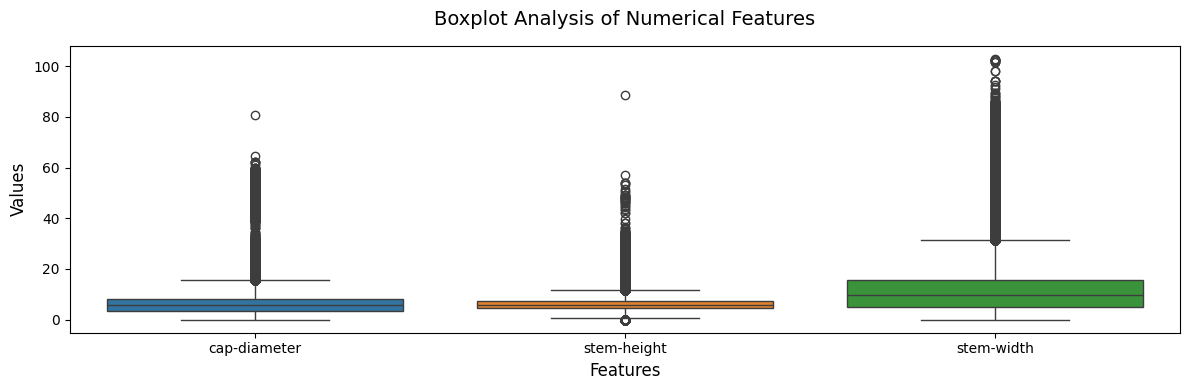

In [15]:
# Boxplot
plt.figure(figsize=(12, 4))
sns.boxplot(data=train_df[num_cols])
plt.title('Boxplot Analysis of Numerical Features', fontsize=14, pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
cat_cols_train = train_df.select_dtypes(include=['object']).columns.tolist()
# Number of unique values in each categorical column
unique_counts_train = train_df[cat_cols_train].nunique().sort_values(ascending=False)

In [17]:
unique_counts_train

cap-surface             83
cap-color               78
gill-attachment         78
cap-shape               74
gill-color              63
stem-surface            60
stem-color              59
habitat                 52
gill-spacing            48
ring-type               40
stem-root               38
spore-print-color       32
does-bruise-or-bleed    26
veil-color              24
has-ring                23
veil-type               22
season                   4
class                    2
dtype: int64

In [18]:
cat_cols_test = test_df.select_dtypes(include=['object']).columns.tolist()
# Number of unique values in each categorical column
unique_counts_test = test_df[cat_cols_test].nunique().sort_values(ascending=False)

In [19]:
unique_counts_test

gill-attachment         66
cap-shape               62
cap-surface             59
cap-color               57
gill-color              56
stem-color              55
stem-surface            54
habitat                 39
ring-type               36
gill-spacing            35
spore-print-color       33
stem-root               31
veil-color              23
has-ring                23
does-bruise-or-bleed    22
veil-type               15
season                   4
dtype: int64

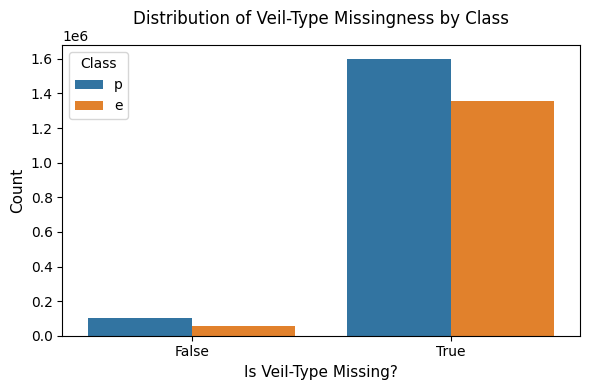

In [20]:
train_df['is_veil_type_missing'] = train_df['veil-type'].isnull()

plt.figure(figsize=(6, 4))
sns.countplot(x='is_veil_type_missing', hue='class', data=train_df)
plt.title('Distribution of Veil-Type Missingness by Class', fontsize=12, pad=15)
plt.xlabel('Is Veil-Type Missing?', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

# Dropping the temporary column after analysis
train_df.drop(columns=['is_veil_type_missing'], inplace=True)

## 4. Data Preprocessing

In [21]:
# 1. Get unique categories as sets (excluding NaNs)
train_cap_shape = set(train_df['cap-shape'].dropna().unique())
test_cap_shape  = set(test_df['cap-shape'].dropna().unique())

# 2. Find categories that are in the test set but NOT in the train set
unseen_test_cap_shape = test_cap_shape - train_cap_shape

In [22]:
unseen_test_cap_shape

{'0.74',
 '0.93',
 '0.97',
 '1.25',
 '1.53',
 '11.43',
 '17.89',
 '19.76',
 '2.02',
 '2.7',
 '3.15',
 '3.23',
 '3.32',
 '3.34',
 '3.47',
 '3.73',
 '3.94',
 '4.41',
 '4.51',
 '4.54',
 '4.55',
 '4.86',
 '5.05',
 '5.59',
 '51.63',
 '6',
 '6.15',
 '6.47',
 '6.52',
 '6.75',
 '9.49',
 'cap-diameter',
 'is f',
 'p f'}

In [23]:
train_cap_color = set(train_df['cap-color'].dropna().unique())
test_cap_color = set(test_df['cap-color'].dropna().unique())

unseen_test_cap_color = test_cap_color - train_cap_color

In [24]:
unseen_test_cap_color

{'0.73',
 '0.91',
 '1.83',
 '10.83',
 '10.93',
 '12.91',
 '17.01',
 '18.49',
 '19.18',
 '2.51',
 '21.38',
 '23.96',
 '24.74',
 '3.0',
 '4.11',
 '4.18',
 '4.5',
 '4.61',
 '4.75',
 '4.92',
 '4.96',
 '5.16',
 '5.35',
 '5.38',
 '6.18',
 '6.74',
 '7.41',
 '9.19',
 'cap---------------------------------------------------------------------------------root',
 'habitat',
 'has-ring'}

In [92]:
## Row Shifting in the data!

# 1. Identify all categorical columns
categorical_columns = train_df.select_dtypes(include=['object']).columns

# 2. Clean train data
for col in categorical_columns:
    train_df[col] = train_df[col].fillna('Missing').astype(str)
    train_df.loc[train_df[col].str.len() > 1, col] = 'Missing'

# 3. Clean test data
for col in categorical_columns:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna('Missing').astype(str)
        test_df.loc[test_df[col].str.len() > 1, col] = 'Missing'

In [34]:
# View basic statistics for numeric columns
train_df[['cap-diameter', 'stem-height', 'stem-width']].describe().T

,count,mean,std,min,25%,50%,75%,max
cap-diameter,3116941.0,6.309848,4.657931,0.03,3.32,5.75,8.24,80.67
stem-height,3116945.0,6.348333,2.699755,0.00,4.67,5.88,7.41,88.72
stem-width,3116945.0,11.153785,8.095477,0.00,4.97,9.65,15.63,102.90


In [93]:
stem_height_median = train_df['stem-height'].median()
stem_width_median = train_df['stem-width'].median()

train_df['stem-height'] = train_df['stem-height'].replace(0.0, stem_height_median)
train_df['stem-width'] = train_df['stem-width'].replace(0.0, stem_width_median)

test_df['stem-height'] = test_df['stem-height'].replace(0.0, stem_height_median)
test_df['stem-width'] = test_df['stem-width'].replace(0.0, stem_width_median)

In [36]:
nan_counts_train = train_df.isna().sum()

nan_counts_train[nan_counts_train > 0]

cap-diameter    4
dtype: int64

In [37]:
nan_counts_test = test_df.isna().sum()

nan_counts_test[nan_counts_test > 0]

cap-diameter    7
stem-height     1
dtype: int64

In [94]:
cap_diameter_median = train_df['cap-diameter'].median()

train_df['cap-diameter'] = train_df['cap-diameter'].fillna(cap_diameter_median)
test_df['cap-diameter'] = test_df['cap-diameter'].fillna(cap_diameter_median)
train_df.isna().sum()[train_df.isna().sum() > 0]

Series([], dtype: int64)

In [95]:
test_df['stem-height'] = test_df['stem-height'].fillna(train_df['stem-height'].median())

test_df.isna().sum()[test_df.isna().sum() > 0]

Series([], dtype: int64)

In [96]:
scaler = RobustScaler()
numeric_features = ['cap-diameter', 'stem-height', 'stem-width']

train_df[numeric_features] = scaler.fit_transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

In [42]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

In [43]:
train_df.isnull().sum()

id                      0
class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-root               0
stem-surface            0
stem-color              0
veil-type               0
veil-color              0
has-ring                0
ring-type               0
spore-print-color       0
habitat                 0
season                  0
dtype: int64

In [44]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

In [45]:
test_df.isnull().sum()

id                      0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-root               0
stem-surface            0
stem-color              0
veil-type               0
veil-color              0
has-ring                0
ring-type               0
spore-print-color       0
habitat                 0
season                  0
dtype: int64

## 5. Model Training, Optimization & Deployment Strategy

In [46]:
train_set, val_set = train_test_split(train_df, test_size=0.2, random_state=42)

In [47]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_set['cap-shape'] = encoder.fit_transform(train_set[['cap-shape']])
val_set['cap-shape'] = encoder.transform(val_set[['cap-shape']])

train_set['cap-surface'] = encoder.fit_transform(train_set[['cap-surface']])
val_set['cap-surface'] = encoder.transform(val_set[['cap-surface']])

train_set['cap-color'] = encoder.fit_transform(train_set[['cap-color']])
val_set['cap-color'] = encoder.transform(val_set[['cap-color']])

train_set['does-bruise-or-bleed'] = encoder.fit_transform(train_set[['does-bruise-or-bleed']])
val_set['does-bruise-or-bleed'] = encoder.transform(val_set[['does-bruise-or-bleed']])

train_set['gill-attachment'] = encoder.fit_transform(train_set[['gill-attachment']])
val_set['gill-attachment'] = encoder.transform(val_set[['gill-attachment']])

train_set['gill-spacing'] = encoder.fit_transform(train_set[['gill-spacing']])
val_set['gill-spacing'] = encoder.transform(val_set[['gill-spacing']])

train_set['gill-color'] = encoder.fit_transform(train_set[['gill-color']])
val_set['gill-color'] = encoder.transform(val_set[['gill-color']])

train_set['stem-root'] = encoder.fit_transform(train_set[['stem-root']])
val_set['stem-root'] = encoder.transform(val_set[['stem-root']])

train_set['stem-surface'] = encoder.fit_transform(train_set[['stem-surface']])
val_set['stem-surface'] = encoder.transform(val_set[['stem-surface']])

train_set['stem-color'] = encoder.fit_transform(train_set[['stem-color']])
val_set['stem-color'] = encoder.transform(val_set[['stem-color']])

train_set['veil-type'] = encoder.fit_transform(train_set[['veil-type']])
val_set['veil-type'] = encoder.transform(val_set[['veil-type']])

train_set['veil-color'] = encoder.fit_transform(train_set[['veil-color']])
val_set['veil-color'] = encoder.transform(val_set[['veil-color']])

train_set['has-ring'] = encoder.fit_transform(train_set[['has-ring']])
val_set['has-ring'] = encoder.transform(val_set[['has-ring']])

train_set['ring-type'] = encoder.fit_transform(train_set[['ring-type']])
val_set['ring-type'] = encoder.transform(val_set[['ring-type']])

train_set['spore-print-color'] = encoder.fit_transform(train_set[['spore-print-color']])
val_set['spore-print-color'] = encoder.transform(val_set[['spore-print-color']])

train_set['habitat'] = encoder.fit_transform(train_set[['habitat']])
val_set['habitat'] = encoder.transform(val_set[['habitat']])

train_set['season'] = encoder.fit_transform(train_set[['season']])
val_set['season'] = encoder.transform(val_set[['season']])

In [48]:
# Create the input dictionary for Train/Validation sets
x_train_dict = {
    'input_cap_shape': train_set['cap-shape'].values,
    'input_cap_surface': train_set['cap-surface'].values,
    'input_cap_color': train_set['cap-color'].values,
    'input_does_bruise_or_bleed': train_set['does-bruise-or-bleed'].values,
    'input_gill_attachment': train_set['gill-attachment'].values,
    'input_gill_spacing': train_set['gill-spacing'].values,
    'input_gill_color': train_set['gill-color'].values,
    'input_stem_root': train_set['stem-root'].values,
    'input_stem_surface': train_set['stem-surface'].values,
    'input_stem_color': train_set['stem-color'].values,
    'input_veil_type': train_set['veil-type'].values,
    'input_veil_color': train_set['veil-color'].values,
    'input_has_ring': train_set['has-ring'].values,
    'input_ring_type': train_set['ring-type'].values,
    'input_spore_print_color': train_set['spore-print-color'].values,
    'input_habitat': train_set['habitat'].values,
    'input_season': train_set['season'].values,
    'input_numeric': train_set[['cap-diameter', 'stem-height', 'stem-width']].values
}

# Same dictionary for Validation set
x_val_dict = {
    'input_cap_shape': val_set['cap-shape'].values,
    'input_cap_surface': val_set['cap-surface'].values,
    'input_cap_color': val_set['cap-color'].values,
    'input_does_bruise_or_bleed': val_set['does-bruise-or-bleed'].values,
    'input_gill_attachment': val_set['gill-attachment'].values,
    'input_gill_spacing': val_set['gill-spacing'].values,
    'input_gill_color': val_set['gill-color'].values,
    'input_stem_root': val_set['stem-root'].values,
    'input_stem_surface': val_set['stem-surface'].values,
    'input_stem_color': val_set['stem-color'].values,
    'input_veil_type': val_set['veil-type'].values,
    'input_veil_color': val_set['veil-color'].values,
    'input_has_ring': val_set['has-ring'].values,
    'input_ring_type': val_set['ring-type'].values,
    'input_spore_print_color': val_set['spore-print-color'].values,
    'input_habitat': val_set['habitat'].values,
    'input_season': val_set['season'].values,
    'input_numeric': val_set[['cap-diameter', 'stem-height', 'stem-width']].values
}

In [49]:
# Assuming 'class' is categorical (e.g., 'p' and 'e')
y_train = train_set['class'].map({'p': 1, 'e': 0}).values
y_val = val_set['class'].map({'p': 1, 'e': 0}).values

In [50]:
# Defining categorical columns
categorical_cols = [
    'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 
    'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 
    'stem-surface', 'stem-color', 'veil-type', 'veil-color', 
    'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season'
]

# Lists to store model components
input_layers = []
embedding_layers = []

# Dynamically create an input and embedding layer for each categorical column
for col in categorical_cols:
    # Determine the number of unique categories (+1 for potential unknown/missing)
    num_unique = int(train_df[col].nunique()) + 1
    
    # Create input layer
    input_layer = Input(shape=(1,), name=f'input_{col.replace("-", "_")}')
    input_layers.append(input_layer)
    
    # Create embedding layer: Embeddings capture semantic relationships between categories
    embedding_dim = min(50, (num_unique + 1) // 2)
    embedding = Embedding(input_dim=num_unique, output_dim=embedding_dim)(input_layer)
    embedding = Flatten()(embedding)
    embedding_layers.append(embedding)

# Numeric input layer (for diameter, height, width)
input_numeric = Input(shape=(3,), name='input_numeric')
input_layers.append(input_numeric)

# Concatenate all features (embeddings + numerical)
all_features = Concatenate()(embedding_layers + [input_numeric])

# Deep Dense layers for learning complex patterns
x = Dense(256, activation='relu')(all_features)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Construct and compile the model
model = Model(inputs=input_layers, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC', 'accuracy'])

2026-05-19 22:19:42.867182: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [54]:
early_stop = EarlyStopping(
    monitor='val_AUC', 
    patience=5, 
    mode='max', 
    restore_best_weights=True,
    verbose=1
)

In [55]:
# Train the model
history = model.fit(
    x_train_dict, 
    y_train,
    validation_data=(x_val_dict, y_val),
    epochs=100,
    batch_size=1024,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - AUC: 0.9971 - accuracy: 0.9927 - loss: 0.0344 - val_AUC: 0.9966 - val_accuracy: 0.9921 - val_loss: 0.0375
Epoch 2/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - AUC: 0.9970 - accuracy: 0.9929 - loss: 0.0341 - val_AUC: 0.9967 - val_accuracy: 0.9921 - val_loss: 0.0375
Epoch 3/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - AUC: 0.9971 - accuracy: 0.9929 - loss: 0.0338 - val_AUC: 0.9967 - val_accuracy: 0.9921 - val_loss: 0.0378
Epoch 4/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - AUC: 0.9971 - accuracy: 0.9930 - loss: 0.0337 - val_AUC: 0.9966 - val_accuracy: 0.9921 - val_loss: 0.0377
Epoch 5/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - AUC: 0.9970 - accuracy: 0.9929 - loss: 0.0341 - val_AUC: 0.9966 - val_accuracy: 0.9921 - val_loss: 0.0376
Epoch 6/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - AUC: 0.9971 - accuracy: 0.9929 - loss: 0.0339 - val_AUC: 0.9968 - val_accuracy: 0.9921 - val_loss: 0.0377
Epoch 7/10

In [58]:
results = model.evaluate(x_val_dict, y_val)

19481/19481 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - AUC: 0.9967 - accuracy: 0.9921 - loss: 0.0375


In [59]:
results

[0.037520088255405426, 0.9967590570449829, 0.9920868277549744]

In [61]:
val_preds = model.predict(x_val_dict).ravel()

19481/19481 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step


In [62]:
fpr, tpr, thresholds = roc_curve(y_val, val_preds)
roc_auc = auc(fpr, tpr)

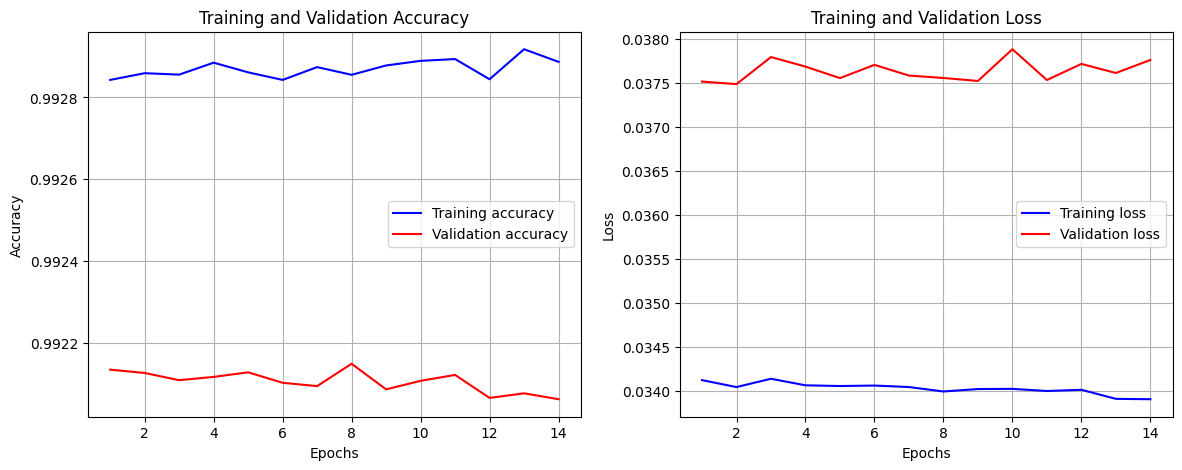

In [66]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plotting Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

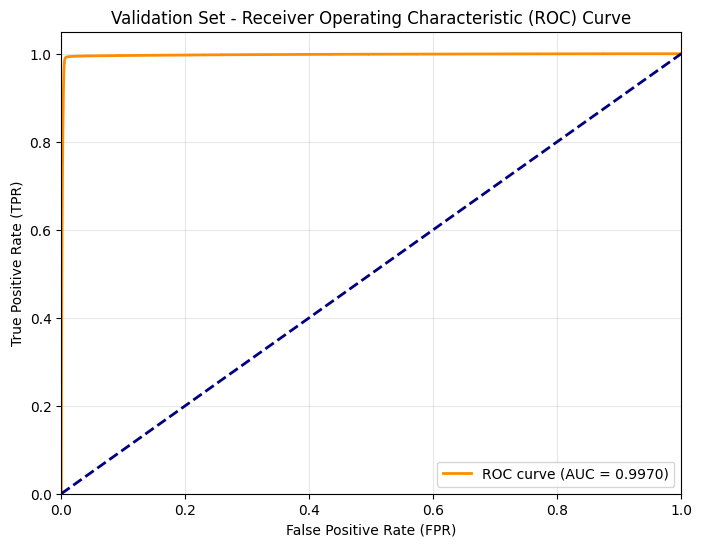

In [63]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Validation Set - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

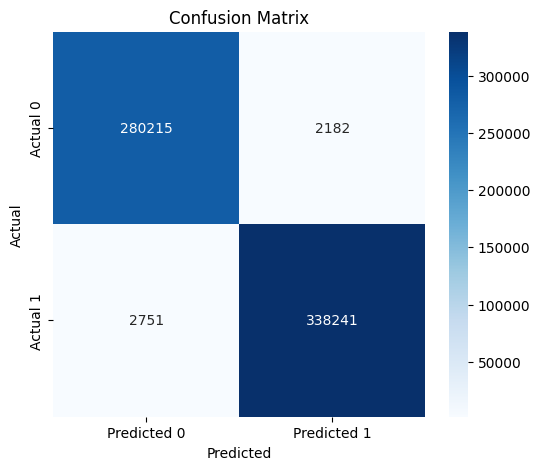

In [65]:
y_pred_class = (val_preds > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [82]:
feature_cols = [col for col in train_df.columns if col != 'class']

test_df = test_df[feature_cols]

train_df[feature_cols].columns.tolist() == test_df.columns.tolist()

True

In [97]:
encoders = {}

categorical_cols = [
    'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 
    'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 
    'stem-surface', 'stem-color', 'veil-type', 'veil-color', 
    'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season'
]

for col in categorical_cols:
    encoders[col] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    train_df[col] = encoders[col].fit_transform(train_df[[col]])
    
    test_df[col] = encoders[col].transform(test_df[[col]])

In [98]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             float64
 4   cap-surface           float64
 5   cap-color             float64
 6   does-bruise-or-bleed  float64
 7   gill-attachment       float64
 8   gill-spacing          float64
 9   gill-color            float64
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             float64
 13  stem-surface          float64
 14  stem-color            float64
 15  veil-type             float64
 16  veil-color            float64
 17  has-ring              float64
 18  ring-type             float64
 19  spore-print-color     float64
 20  habitat               float64
 21  season                float64
dtypes: float64(20), int64(1), object(1)
memory

In [99]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2077964 entries, 0 to 2077963
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   cap-diameter          float64
 2   cap-shape             float64
 3   cap-surface           float64
 4   cap-color             float64
 5   does-bruise-or-bleed  float64
 6   gill-attachment       float64
 7   gill-spacing          float64
 8   gill-color            float64
 9   stem-height           float64
 10  stem-width            float64
 11  stem-root             float64
 12  stem-surface          float64
 13  stem-color            float64
 14  veil-type             float64
 15  veil-color            float64
 16  has-ring              float64
 17  ring-type             float64
 18  spore-print-color     float64
 19  habitat               float64
 20  season                float64
dtypes: float64(20), int64(1)
memory usage: 332.9 MB


In [100]:
x_train_dict = {
    'input_cap_shape': train_df['cap-shape'].values,
    'input_cap_surface': train_df['cap-surface'].values,
    'input_cap_color': train_df['cap-color'].values,
    'input_does_bruise_or_bleed': train_df['does-bruise-or-bleed'].values,
    'input_gill_attachment': train_df['gill-attachment'].values,
    'input_gill_spacing': train_df['gill-spacing'].values,
    'input_gill_color': train_df['gill-color'].values,
    'input_stem_root': train_df['stem-root'].values,
    'input_stem_surface': train_df['stem-surface'].values,
    'input_stem_color': train_df['stem-color'].values,
    'input_veil_type': train_df['veil-type'].values,
    'input_veil_color': train_df['veil-color'].values,
    'input_has_ring': train_df['has-ring'].values,
    'input_ring_type': train_df['ring-type'].values,
    'input_spore_print_color': train_df['spore-print-color'].values,
    'input_habitat': train_df['habitat'].values,
    'input_season': train_df['season'].values,
    'input_numeric': train_df[['cap-diameter', 'stem-height', 'stem-width']].values
}

x_test_dict = {k: test_df[k.replace('input_', '').replace('_', '-')].values if k != 'input_numeric' else test_df[['cap-diameter', 'stem-height', 'stem-width']].values for k in x_train_dict.keys()}

In [101]:
y_train = train_df['class'].map({'p': 1, 'e': 0}).values

In [102]:
early_stop = EarlyStopping(
    monitor='loss', 
    patience=3,
    mode='min',
    restore_best_weights=True 
)

In [103]:
history = model.fit(
    x_train_dict, 
    y_train, 
    epochs=100, 
    batch_size=1024, 
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - AUC: 0.9963 - accuracy: 0.9902 - loss: 0.0422
Epoch 2/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - AUC: 0.9969 - accuracy: 0.9925 - loss: 0.0356
Epoch 3/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - AUC: 0.9969 - accuracy: 0.9927 - loss: 0.0348
Epoch 4/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - AUC: 0.9969 - accuracy: 0.9926 - loss: 0.0350
Epoch 5/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - AUC: 0.9970 - accuracy: 0.9927 - loss: 0.0348
Epoch 6/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - AUC: 0.9970 - accuracy: 0.9927 - loss: 0.0346
Epoch 7/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - AUC: 0.9970 - accuracy: 0.9927 - loss: 0.0346
Epoch 8/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - AUC: 0.9970 - accuracy: 0.9927 - loss: 0.0347
Epoch 9/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - AUC: 0.9970 - accuracy: 0.9927 - loss: 0.0348
Epoch 10/100
3044/3044 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/st

In [105]:
final_preds = model.predict(x_test_dict)

64937/64937 ━━━━━━━━━━━━━━━━━━━━ 139s 2ms/step


In [106]:
final_preds_binary = (final_preds.squeeze() > 0.5).astype(int)

In [107]:
final_preds_labels = np.where(final_preds_binary == 1, 'p', 'e')

In [108]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'class': final_preds_labels
})

submission_df.to_csv('submission.csv', index=False)

In [109]:
submission_df

,id,class
0,3116945,e
1,3116946,p
2,3116947,p
3,3116948,p
4,3116949,e
...,...,...
2077959,5194904,p
2077960,5194905,p
2077961,5194906,p
2077962,5194907,e


In [110]:
model.save('mushroom_final_model.keras')

In [111]:
import pickle

with open('mushroom_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)